In [10]:
# Celda 1: Importaciones y configuración general
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo (tamaños aumentados)
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 20,
    'figure.figsize': (12, 7.5),
    'axes.linewidth': 2.0,
    'axes.edgecolor': 'black',
    'axes.facecolor': 'white'
})

# Colores
color_nodo = '#1f78b4'
color_enlace = '#a6cee3'
color_destacado = '#e31a23'
color_hub = '#ff7f00'
color_comunidad = ['#33a02c', '#6a3d9a', '#b15928', '#ffff99']

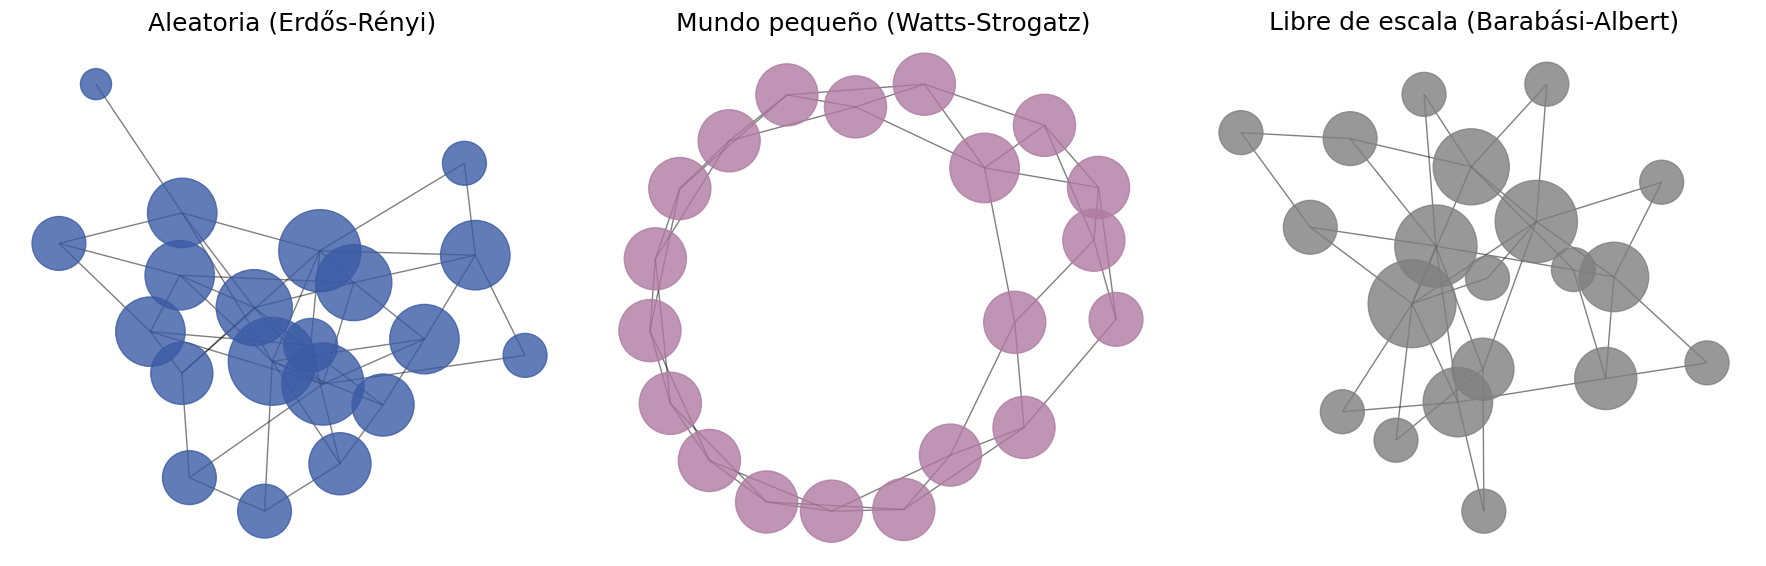

In [11]:
# Celda 9: Visualización de redes pequeñas (aleatoria, mundo pequeño, libre de escala)
# Crear redes pequeñas para mostrar topologías
N_peq = 20
G_er_peq = nx.erdos_renyi_graph(N_peq, 0.2)
G_ws_peq = nx.watts_strogatz_graph(N_peq, 4, 0.1)
G_ba_peq = nx.barabasi_albert_graph(N_peq, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
redes = [G_er_peq, G_ws_peq, G_ba_peq]
titulos = ['Aleatoria (Erdős-Rényi)', 'Mundo pequeño (Watts-Strogatz)', 'Libre de escala (Barabási-Albert)']

# Lista de colores (uno por red)
colores = ['#3B5BA5',  # azul académico
           '#B07AA1',  # morado suave
           '#7F7F7F']  # gris neutro

for ax, G, tit, color in zip(axes, redes, titulos, colores):
    pos = nx.spring_layout(G, seed=42)
    # Tamaño de nodos proporcional al grado
    node_size = [500 * d for n, d in G.degree()]

    nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color=color,
        alpha=0.8,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos, alpha=0.5, ax=ax)
    ax.set_title(tit, fontsize=18)
    ax.axis('off')

plt.tight_layout()
#plt.savefig('tipos_redes.png', dpi=150, bbox_inches='tight')
plt.show()

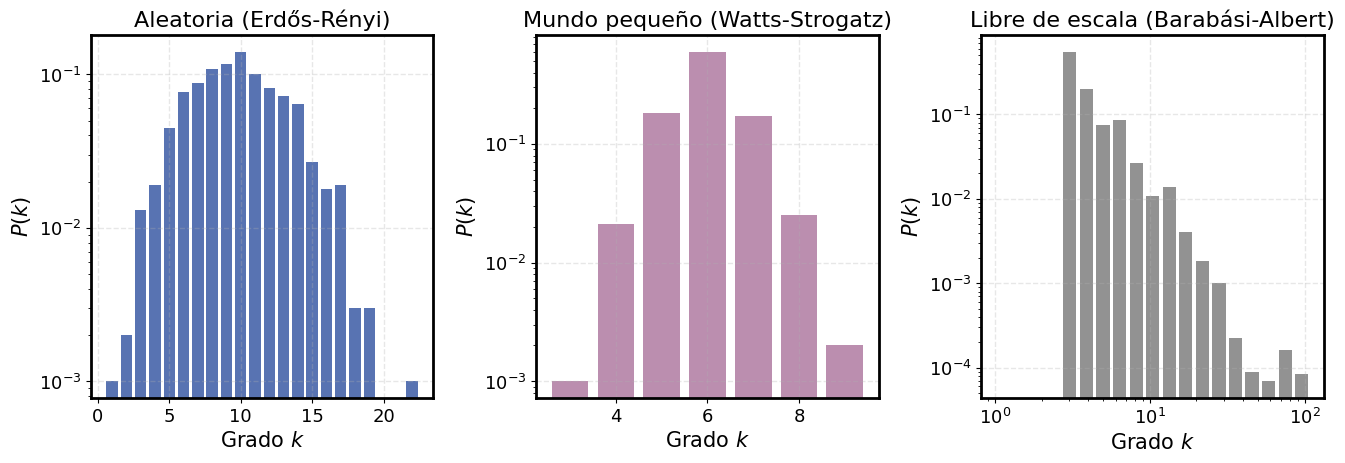

In [12]:
# Celda: Distribuciones de grado para redes canónicas (versión mejorada, sin solapamiento)

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Parámetros para LaTeX
ancho_cm = 36                    # ancho total en centímetros (aumentado)
ancho_pulg = ancho_cm / 2.54      # convertir a pulgadas
dpi = 600                         # resolución para PNG

# Crear redes de ejemplo
N = 1000
G_er = nx.erdos_renyi_graph(N, 0.01)
G_ws = nx.watts_strogatz_graph(N, 6, 0.1)
G_ba = nx.barabasi_albert_graph(N, 3)

redes = [G_er, G_ws, G_ba]
titulos = ['Aleatoria (Erdős-Rényi)', 'Mundo pequeño (Watts-Strogatz)', 'Libre de escala (Barabási-Albert)']
colores = ['#3B5BA5', '#B07AA1', '#7F7F7F']  # azul, morado, gris

fig, axes = plt.subplots(1, 3, figsize=(ancho_pulg, ancho_pulg * 0.35))

for ax, G, tit, color in zip(axes, redes, titulos, colores):
    grados = [d for n, d in G.degree()]

    # Selección de bins según el tipo de red
    if G == G_ba:
        bins = np.logspace(np.log10(1), np.log10(max(grados)), 20)
        ax.set_xscale('log')
    else:
        bins = np.arange(min(grados), max(grados) + 2) - 0.5
        ax.set_xscale('linear')

    hist, bins = np.histogram(grados, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.bar(bin_centers, hist, width=np.diff(bins) * 0.8, color=color, alpha=0.85, align='center')

    ax.set_title(tit, fontsize=16)
    ax.set_xlabel('Grado $k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)

# Ajustar espaciado manualmente
plt.subplots_adjust(wspace=0.3, left=0.08, right=0.95, top=0.88, bottom=0.15)

# Guardar en formatos adecuados
#plt.savefig('distribuciones_grado.pdf', bbox_inches='tight')
#plt.savefig('distribuciones_grado.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [13]:
# Celda de preámbulo: Configuración global de estilo
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# Configuración de estilo al estilo Barabási (Network Science) con tamaños aumentados
plt.rcParams.update({
    'font.size': 18,               # Tamaño de fuente global
    'axes.titlesize': 20,           # Tamaño de los títulos de los ejes
    'axes.labelsize': 18,           # Tamaño de las etiquetas de los ejes
    'xtick.labelsize': 16,          # Tamaño de los números del eje x
    'ytick.labelsize': 16,          # Tamaño de los números del eje y
    'legend.fontsize': 16,          # Tamaño de la leyenda
    'figure.titlesize': 20,          # Tamaño del título de la figura
    'axes.linewidth': 2.0,           # Grosor de los bordes de los ejes
    'axes.edgecolor': 'black',       # Color de los bordes de los ejes
    'axes.facecolor': 'white'        # Fondo blanco para los ejes
})

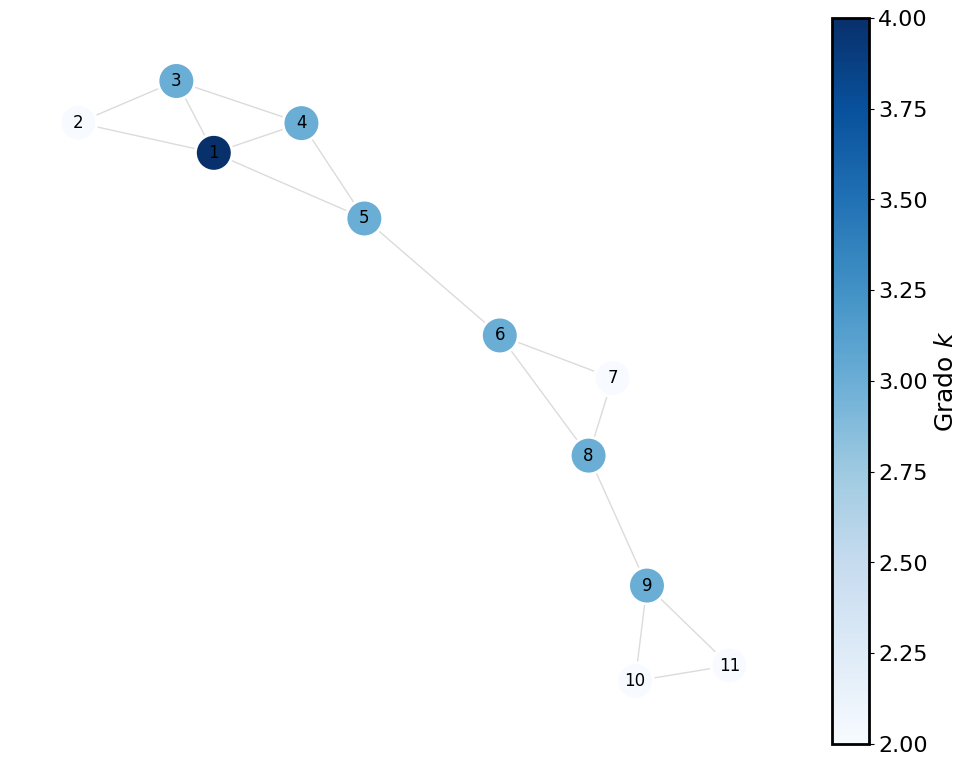

In [14]:
# Celda 2: Grado (red pequeña) - Solo grafo
# Crear una red pequeña para ilustrar
G = nx.Graph()
G.add_edges_from([
    (1,2), (1,3), (1,4), (1,5),
    (2,3), (3,4), (4,5), (5,6),
    (6,7), (6,8), (7,8), (8,9),
    (9,10), (9,11), (10,11)
])

grados = dict(G.degree())

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Grafo con nodos coloreados por grado
pos = nx.spring_layout(G, seed=42)
nodes = nx.draw_networkx_nodes(
    G, pos, node_color=list(grados.values()),
    cmap=plt.cm.Blues, node_size=700, ax=ax, edgecolors='white', linewidths=2.0
)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black', ax=ax)
#ax.set_title('Nodos coloreados por grado', fontsize=14)
plt.colorbar(nodes, ax=ax, label='Grado $k$', fraction=0.046, pad=0.04)
ax.axis('off')

plt.tight_layout()
plt.savefig('grado_juguete.png', dpi=300, bbox_inches='tight')
plt.show()

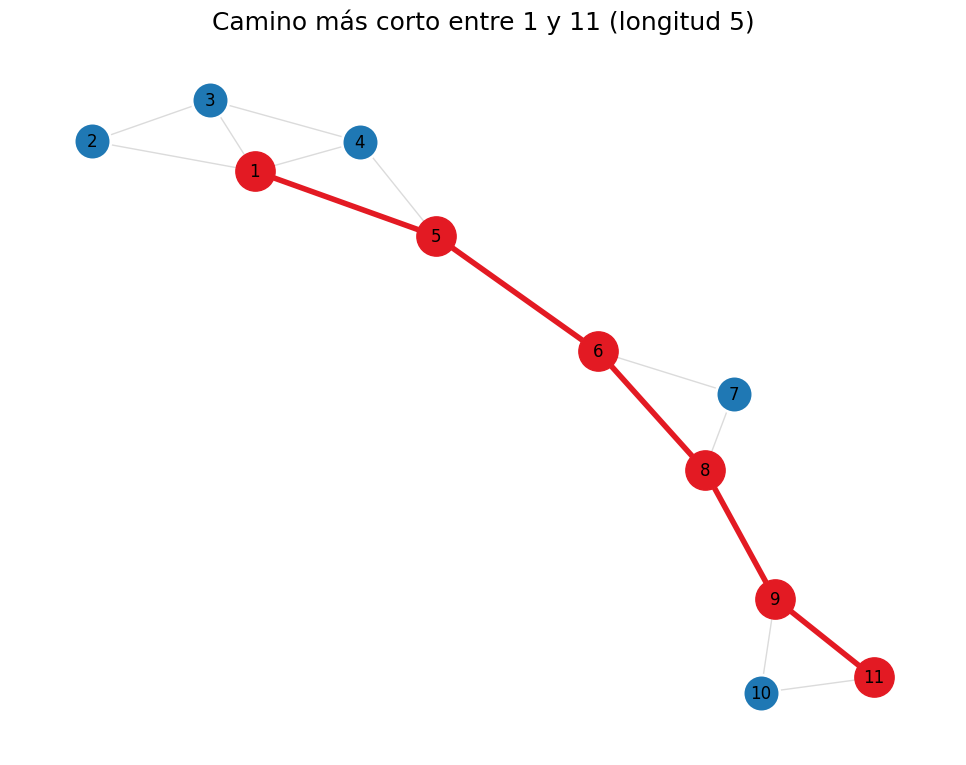

In [15]:
# Celda 4: Caminos - Solo grafo (camino más corto)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Grafo con camino más corto destacado
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color='#1f78b4', node_size=700, ax=ax, edgecolors='white', linewidths=2.0)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black', ax=ax)

# Camino más corto entre nodo 1 y 11
path = nx.shortest_path(G, source=1, target=11)
edges_path = [(path[i], path[i+1]) for i in range(len(path)-1)]
nx.draw_networkx_edges(G, pos, edgelist=edges_path, width=4, edge_color='#e31a23', ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='#e31a23', node_size=800, ax=ax)
ax.set_title(f'Camino más corto entre 1 y 11 (longitud {len(path)-1})', fontsize=18)
ax.axis('off')

plt.tight_layout()
plt.savefig('distancia_juguete.png', dpi=300, bbox_inches='tight')
plt.show()

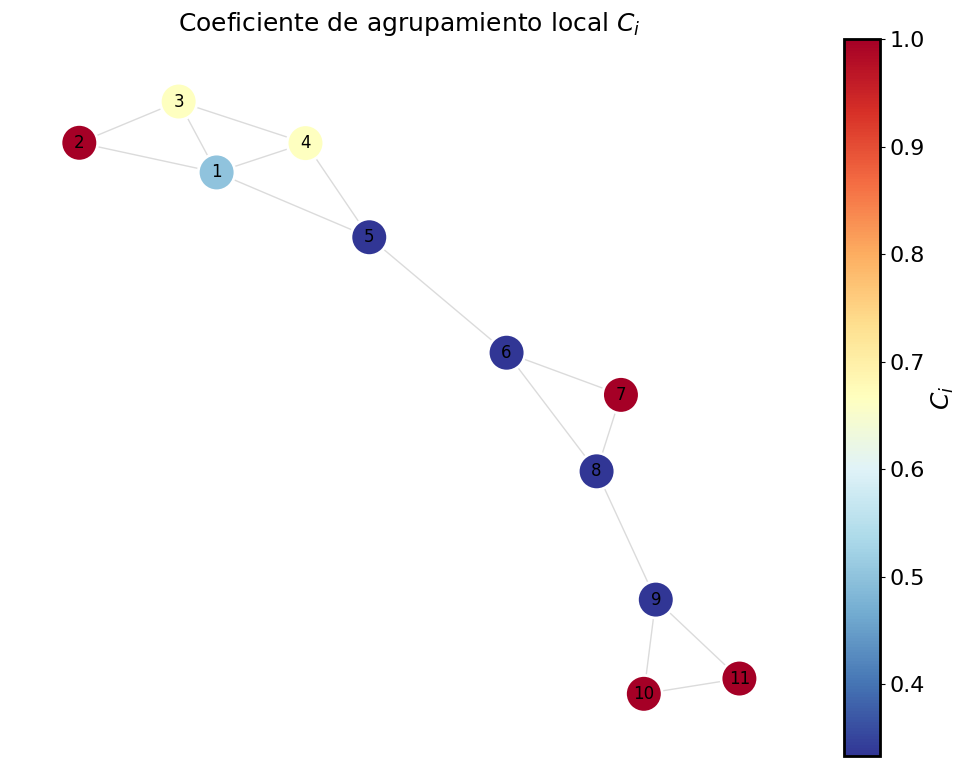

In [16]:
# Celda 5: Coeficiente de agrupamiento (clustering) - Solo grafo
clustering_local = nx.clustering(G)
clustering_global = nx.average_clustering(G)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Grafo con nodos coloreados por clustering
pos = nx.spring_layout(G, seed=42)
nodes = nx.draw_networkx_nodes(
    G, pos, node_color=list(clustering_local.values()),
    cmap=plt.cm.RdYlBu_r, node_size=700, ax=ax, edgecolors='white', linewidths=2.0
)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black', ax=ax)
ax.set_title('Coeficiente de agrupamiento local $C_i$', fontsize=18)
plt.colorbar(nodes, ax=ax, label='$C_i$', fraction=0.046, pad=0.04)
ax.axis('off')

plt.tight_layout()
plt.savefig('cluster_juguete.png', dpi=300, bbox_inches='tight')
plt.show()

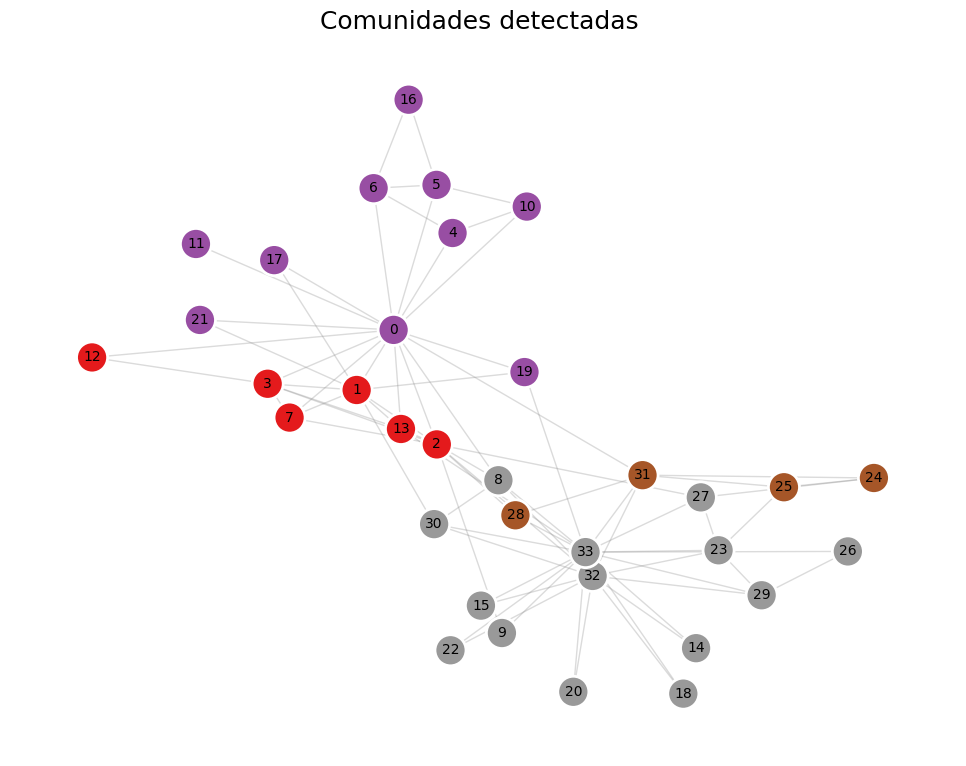

In [17]:
# Celda 7: Modularidad y comunidades (Louvain) - Solo grafo
G_comm = nx.karate_club_graph()

from networkx.algorithms.community import louvain_communities, modularity

communities = louvain_communities(G_comm, seed=42)
partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i

mod = modularity(G_comm, communities)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Grafo coloreado por comunidades
pos = nx.spring_layout(G_comm, seed=42)
colors = [partition[n] for n in G_comm.nodes()]
nx.draw_networkx_nodes(G_comm, pos, node_color=colors, cmap=plt.cm.Set1, node_size=500, ax=ax, edgecolors='white', linewidths=2.0)
nx.draw_networkx_edges(G_comm, pos, alpha=0.3, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G_comm, pos, font_size=10, font_color='black', ax=ax)
ax.set_title(f'Comunidades detectadas ', fontsize=18)
ax.axis('off')

plt.tight_layout()
plt.savefig('modularidad_juguete.png', dpi=300, bbox_inches='tight')
plt.show()

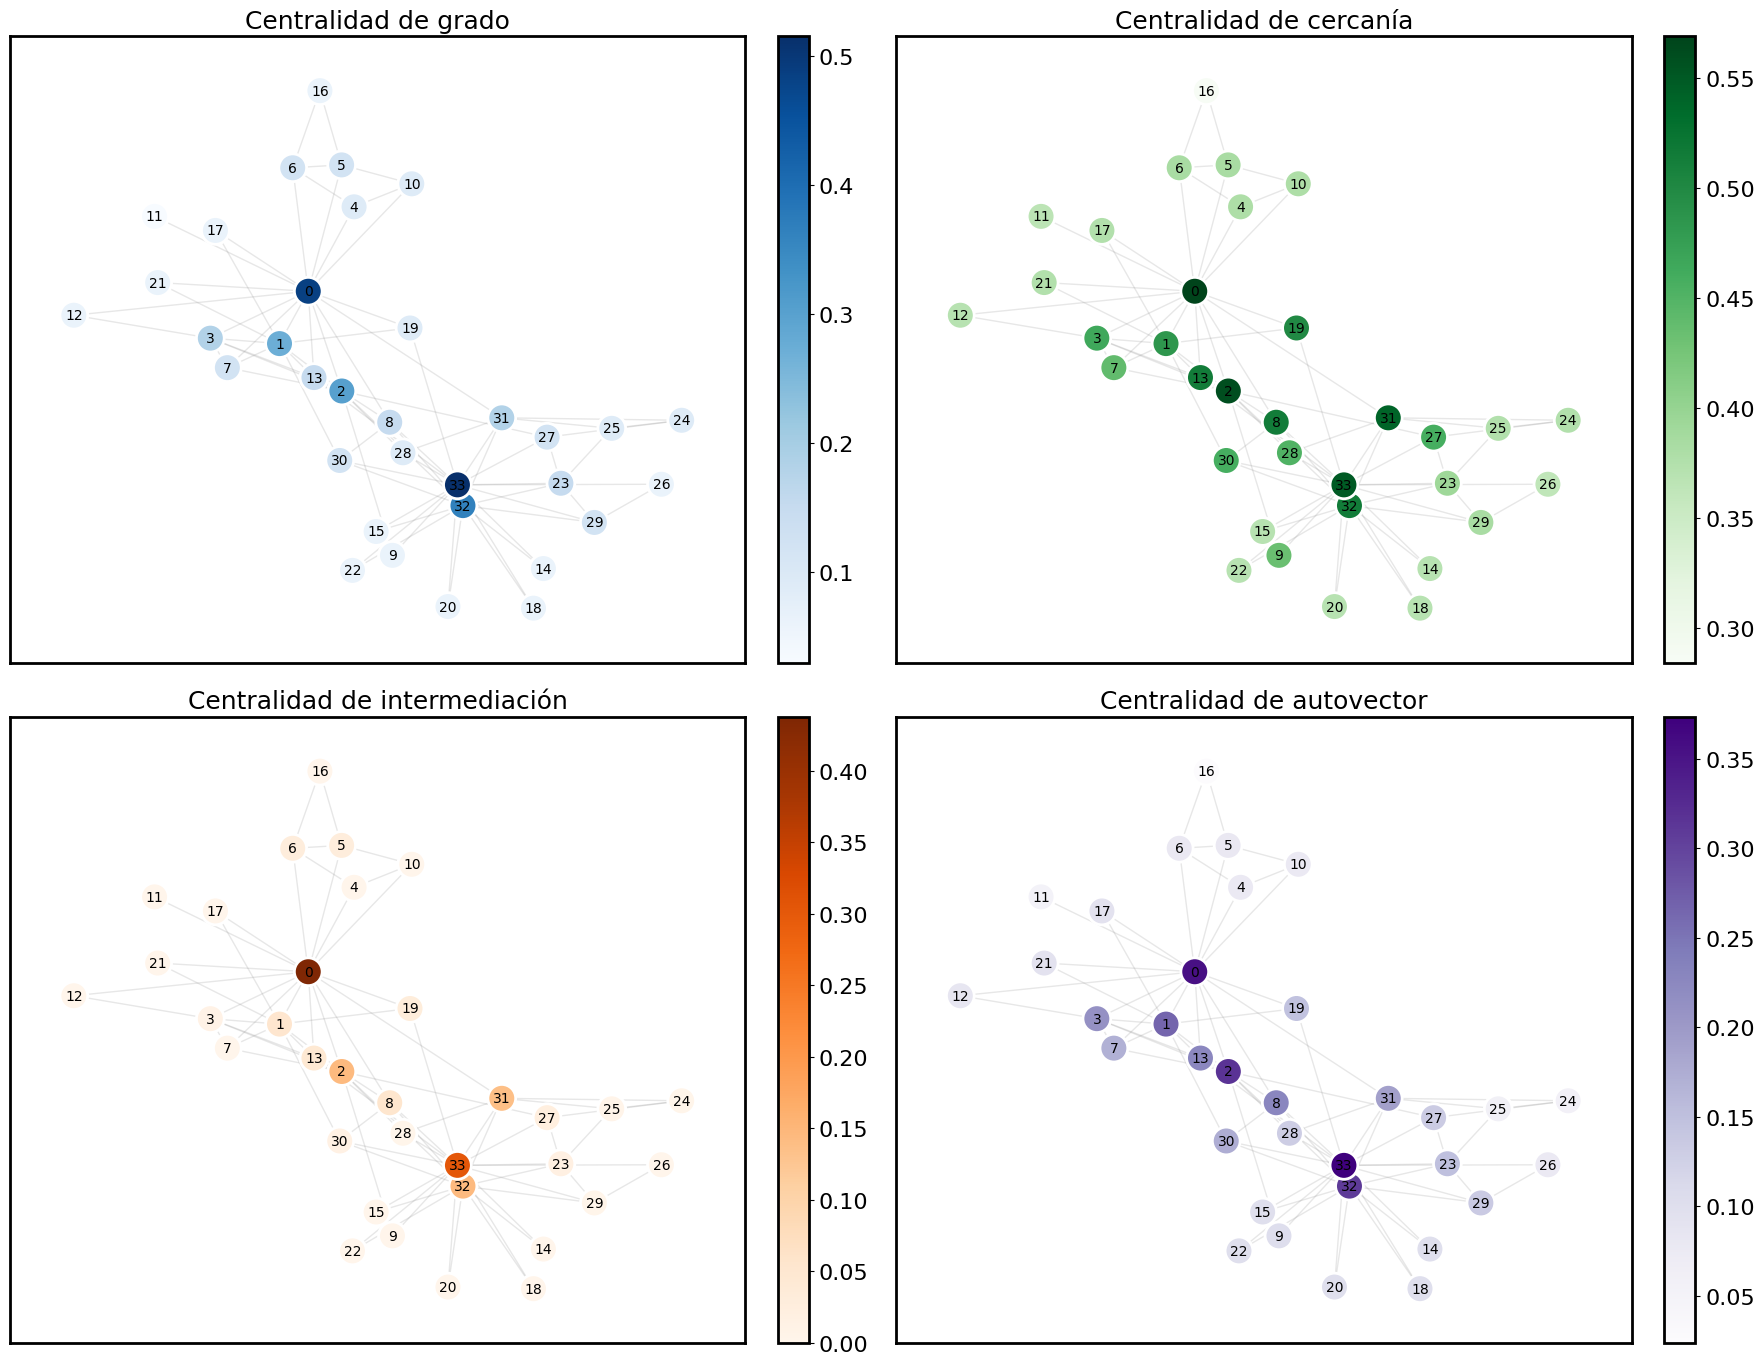

In [18]:
# Celda 6: Centralidades
G_central = nx.karate_club_graph()

deg_c = nx.degree_centrality(G_central)
close_c = nx.closeness_centrality(G_central)
between_c = nx.betweenness_centrality(G_central)
eigen_c = nx.eigenvector_centrality(G_central, max_iter=1000)

centralities = [deg_c, close_c, between_c, eigen_c]
titles = ['Centralidad de grado', 'Centralidad de cercanía',
          'Centralidad de intermediación', 'Centralidad de autovector']
cmaps = [plt.cm.Blues, plt.cm.Greens, plt.cm.Oranges, plt.cm.Purples]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
pos = nx.spring_layout(G_central, seed=42)

for ax, cent, title, cmap in zip(axes.flat, centralities, titles, cmaps):
    nodes = nx.draw_networkx_nodes(
        G_central, pos, node_color=list(cent.values()),
        cmap=cmap, node_size=400, ax=ax, edgecolors='white', linewidths=2.0
    )
    nx.draw_networkx_edges(G_central, pos, alpha=0.2, edge_color='#888888', ax=ax)
    nx.draw_networkx_labels(G_central, pos, font_size=10, font_color='black', ax=ax)
    ax.set_title(title, fontsize=18)
    plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('centralidad_juguete.png', dpi=300, bbox_inches='tight')
plt.show()